In [1]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import umap
import hdbscan
import matplotlib.pyplot as plt
import pickle
from tqdm.notebook import tqdm

In [2]:
cur_dir = os.getcwd().split('\\')

if cur_dir[-1] == 'notebooks':
    os.chdir("..")

from utils.data_load_utilities.data_loader import load_model_results
from utils.get_global_const import get_global_const
from utils.get_metrics import get_metrics
from utils.get_ranks import get_ranks_s, get_ranks
from methods.ADoE_method import *
from methods.k_nearest_methods import *
from methods.kmeans_methods import *
from methods.opt_methods import *
from methods.sparce_methods import *
from methods.entrophy_metods import *

from testing_pipeline.testing_pipeline_stats import *

from sklearn.linear_model import LassoCV
from sklearn.feature_selection import mutual_info_regression

from datetime import datetime
import re

import warnings
warnings.simplefilter('ignore')

In [3]:
scores, datasets, models = get_global_const()
scores

Parsing Bakeoff2017 models...

Parsing Bakeoff2021 models...

Parsing Bakeoff2023 models...

Parsing HIVE-COTEV2 models...



{'1NN-DTW':                   folds:         0         1         2         3         4  \
 0                  Adiac  0.603581  0.603581  0.601023  0.606138  0.608696   
 1              ArrowHead  0.702857  0.742857  0.680000  0.708571  0.760000   
 2                   Beef  0.633333  0.533333  0.533333  0.500000  0.566667   
 3              BeetleFly  0.700000  0.800000  0.650000  0.800000  0.650000   
 4            BirdChicken  0.750000  0.850000  0.950000  0.800000  0.950000   
 ..                   ...       ...       ...       ...       ...       ...   
 107  EOGHorizontalSignal  0.441989  0.607735  0.566298  0.569061  0.624309   
 108    EOGVerticalSignal  0.433702  0.511050  0.549724  0.566298  0.563536   
 109                 Rock  0.540000  0.680000  0.660000  0.640000  0.720000   
 110                 Crop  0.710536  0.713631  0.706964  0.708929  0.712321   
 111            Chinatown  0.973761  0.909621  0.953353  0.944606  0.970845   
 
             5         6         7     

In [4]:
tsfresh_features = pd.read_csv(Path('data/datasets_features/tsfresh_important_features.csv'), index_col=0)
# tsfresh_features

In [5]:
# chosen_datasets = tsfresh_features.Name.values
chosen_datasets = datasets
chosen_datasets[:5]

['Adiac', 'ArrowHead', 'Beef', 'BeetleFly', 'BirdChicken']

In [6]:
features = pd.read_csv(Path('data/datasets_features/features.csv'), index_col=0)
features = features.set_index('Name')
features = features.loc[chosen_datasets, :]
features = features.reset_index()
features

,Name,entropy,gini,number_of_classes,size
0,Adiac,5.202000,0.972675,1.0,781.0
1,ArrowHead,1.576854,0.662833,1.0,211.0
2,Beef,2.321928,0.800000,1.0,60.0
3,BeetleFly,1.000000,0.500000,0.0,40.0
4,BirdChicken,1.000000,0.500000,0.0,40.0
...,...,...,...,...,...
107,EOGHorizontalSignal,3.584885,0.916658,1.0,724.0
108,EOGVerticalSignal,3.584885,0.916658,1.0,724.0
109,Rock,1.925301,0.723673,1.0,70.0
110,Crop,4.584963,0.958333,1.0,24000.0


In [7]:
scores_aggr = {
    model: model_score[model_score["folds:"].isin(chosen_datasets)].reset_index(drop=True) for model, model_score in scores.items()
}

scores_aggr = {
    model: model_score.set_index("folds:").loc[chosen_datasets, :].reset_index() for model, model_score in scores_aggr.items()
}

scores_aggr = {
    model: model_score[model_score.columns[1:]].mean(axis=1) for model, model_score in scores_aggr.items()
}

scores_aggr = pd.DataFrame(scores_aggr)

scores_aggr

,1NN-DTW,Arsenal,BOSS,CIF,CNN,Catch22,DrCIF,EE,FreshPRINCE,HC1,...,STSF,ShapeDTW,Signatures,TDE,TS-CHIEF,TSF,TSFresh,WEASEL-D,WEASEL,cBOSS
0,0.603410,0.769224,0.745695,0.766922,0.387383,0.697187,0.811679,0.657374,0.808355,0.790878,...,0.813384,0.653367,0.700256,0.754902,0.779710,0.715686,0.789770,0.817818,0.793606,0.745780
1,0.722095,0.864762,0.860000,0.823238,0.759810,0.760000,0.828000,0.860381,0.788381,0.877524,...,0.789143,0.856000,0.773333,0.897524,0.881143,0.784190,0.613143,0.885143,0.879429,0.881714
2,0.504444,0.751111,0.630000,0.792222,0.667778,0.484444,0.794444,0.515556,0.791111,0.718889,...,0.790000,0.530000,0.632222,0.664444,0.632222,0.677778,0.734444,0.776667,0.718889,0.577778
3,0.775000,0.886667,0.940000,0.855000,0.791667,0.851667,0.885000,0.756667,0.881667,0.953333,...,0.905000,0.703333,0.761667,0.931667,0.958333,0.823333,0.500000,0.946667,0.920000,0.960000
4,0.840000,0.891667,0.980000,0.868333,0.705000,0.888333,0.951667,0.836667,0.923333,0.965000,...,0.961667,0.690000,0.691667,0.968333,0.963333,0.821667,0.608333,0.933333,0.906667,0.981667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,0.591344,0.804788,0.680387,0.782689,0.500829,0.724862,0.797514,0.782320,0.768508,0.797145,...,0.738674,0.646869,0.696409,0.719153,0.853683,0.692910,0.751197,0.749724,0.688858,0.710313
108,0.534807,0.774954,0.632965,0.763996,0.359300,0.674954,0.780295,0.736004,0.696041,0.760221,...,0.734162,0.539227,0.619797,0.693186,0.809484,0.663628,0.680018,0.691529,0.553131,0.639134
109,0.655333,0.804000,0.796667,0.830000,0.716000,0.766000,0.848000,0.757333,0.847333,0.862000,...,0.818667,0.701333,0.748000,0.870667,0.832000,0.764667,0.644667,0.876667,0.854000,0.808000
110,0.710748,0.739889,0.690855,0.778077,0.706524,0.691712,0.779589,0.732292,0.767915,0.768135,...,0.764036,0.713845,0.753990,0.718905,0.762101,0.751514,0.756284,0.758688,0.737942,0.701365


In [8]:
prep_features = features.copy()
prep_features = prep_features.drop(columns=['Name'])
prep_features['size'] = np.log(prep_features['size'])
prep_features

,entropy,gini,number_of_classes,size
0,5.202000,0.972675,1.0,6.660575
1,1.576854,0.662833,1.0,5.351858
2,2.321928,0.800000,1.0,4.094345
3,1.000000,0.500000,0.0,3.688879
4,1.000000,0.500000,0.0,3.688879
...,...,...,...,...
107,3.584885,0.916658,1.0,6.584791
108,3.584885,0.916658,1.0,6.584791
109,1.925301,0.723673,1.0,4.248495
110,4.584963,0.958333,1.0,10.085809


In [9]:
prep_tsfresh_features = tsfresh_features.copy()
prep_tsfresh_features = prep_tsfresh_features.drop(columns=['Name'])
prep_tsfresh_features

,value__variance_larger_than_standard_deviation,value__has_duplicate_max,value__has_duplicate_min,value__has_duplicate,value__sum_values,value__abs_energy,value__mean_abs_change,value__mean_change,value__mean_second_derivative_central,value__median,...,value__fourier_entropy__bins_5,value__fourier_entropy__bins_10,value__fourier_entropy__bins_100,value__permutation_entropy__dimension_3__tau_1,value__permutation_entropy__dimension_4__tau_1,value__permutation_entropy__dimension_5__tau_1,value__permutation_entropy__dimension_6__tau_1,value__permutation_entropy__dimension_7__tau_1,value__query_similarity_count__query_None__threshold_0.0,value__mean_n_absolute_max__number_of_maxima_7
0,0,0,0,1,0,0,1,1,1,1,...,1,1,1,1,1,1,1,1,0,1
1,0,0,0,0,0,0,1,1,0,1,...,1,1,1,1,1,1,1,1,0,1
2,0,0,0,0,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,1,1,0,1,...,0,0,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104,0,0,0,0,1,1,1,1,0,1,...,1,1,1,1,1,1,1,1,0,1
105,0,1,0,0,1,1,1,1,1,1,...,1,1,1,0,0,0,0,0,0,1
106,0,0,0,0,1,1,1,1,0,1,...,1,0,1,1,1,1,1,1,0,1
107,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,0,1


In [10]:
nn_clusters = [2, 3, 4, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 109]

In [11]:
chosen_datasets = np.array(chosen_datasets)

In [12]:
ranks = get_ranks_s(chosen_datasets, scores, datasets, return_ranks=True)
ranks_all = get_ranks_s(chosen_datasets, scores, datasets, return_ranks=False)

In [13]:
# 1/0

In [14]:
# ranks

In [15]:
metrics = ['MAE', 'MSE', 'Kendall', 'Spearman', 'Pearson', 'Mutual information', 'Adjusted mutual information', 'Normalized mutual information', 'Cramers V', 'Point-Biserial Correlation', 'Phi Coefficient', 'Bloomquist Beta', 'Rank Correlation Ratio', 'Xi Correlation', 'Distance Correlation', 'Me', 'repr']

In [16]:
def random_ind_metr(data: pd.DataFrame, indexes_list, sample_size: int, test_ind, datasets, iter=100, inner_iter=10):
    
    sum_metrics = None
    
    for i in range(iter):
        
        for _ in range(inner_iter):
        
            data_train = data.loc[indexes_list[i]]
            
            indxs = np.random.choice(data_train.index, sample_size, replace=False)
            
            repr_simple = chosen_datasets[[indxs]].squeeze()
        
            ranks_simple = get_ranks(repr_simple, ranks)
            metr = get_metrics(get_ranks(datasets[test_ind].squeeze(), ranks), ranks_simple)
            
            if sum_metrics is None:
                sum_metrics = metr.copy()
            else:
                for key in sum_metrics:
                    sum_metrics[key] += metr[key]

    averaged_metrics = {key: value / (iter * inner_iter) for key, value in sum_metrics.items()}

    return averaged_metrics
    

In [17]:
targets = np.array(scores_aggr.mean(axis=1))

In [18]:
tsfresh_features_full = pd.read_csv(Path('data/datasets_features/tsfresh_full_features.csv'), index_col=0)
prep_tsfresh_features_full = tsfresh_features_full.copy().set_index("Name").loc[chosen_datasets, :]
prep_tsfresh_features_full = prep_tsfresh_features_full.reset_index().drop(columns=['Name'])
prep_tsfresh_features_full = prep_tsfresh_features_full.dropna(axis=1)
prep_tsfresh_features_full = prep_tsfresh_features_full.drop(columns=prep_tsfresh_features_full.columns[(prep_tsfresh_features_full.abs() > 1e9).any()])
constant_features = [col for col in prep_tsfresh_features_full.columns if prep_tsfresh_features_full[col].nunique() <= 1]
prep_tsfresh_features_full = prep_tsfresh_features_full.drop(columns=constant_features)
prep_tsfresh_features_full

,v__variance_larger_than_standard_deviation,v__has_duplicate_max,v__has_duplicate_min,v__has_duplicate,v__sum_values,v__mean_abs_change,v__mean_change,v__mean_second_derivative_central,v__median,v__mean,...,v__fourier_entropy__bins_3,v__fourier_entropy__bins_5,v__fourier_entropy__bins_10,v__fourier_entropy__bins_100,v__permutation_entropy__dimension_3__tau_1,v__permutation_entropy__dimension_4__tau_1,v__permutation_entropy__dimension_5__tau_1,v__permutation_entropy__dimension_6__tau_1,v__permutation_entropy__dimension_7__tau_1,v__mean_n_absolute_max__number_of_maxima_7
0,0.0,0.002561,0.000000,0.040973,1.595424e-08,0.070771,-0.000006,0.000125,-0.098502,9.064907e-11,...,0.073411,0.168004,0.176986,0.223225,0.879698,1.039076,1.177104,1.299305,1.411905,1.698952
1,0.0,0.142180,0.018957,0.909953,1.318861e-08,0.054496,0.000015,-0.000024,0.078746,5.254427e-11,...,0.083061,0.113604,0.141103,0.245041,1.214883,1.688473,2.082949,2.389370,2.631711,1.885942
2,0.0,0.000000,0.000000,0.916667,-1.127247e-08,0.037038,-0.003015,0.000002,0.081233,-2.398397e-11,...,0.065581,0.112057,0.184807,0.411851,1.281744,1.912363,2.498251,2.984730,3.366054,2.572998
3,0.0,0.025000,0.025000,1.000000,-6.466022e-08,0.087903,-0.000121,0.000080,-0.039787,-1.262895e-10,...,0.161443,0.210911,0.263460,0.446413,0.992351,1.291133,1.582449,1.860685,2.127973,2.192153
4,0.0,0.000000,0.025000,1.000000,-7.175370e-08,0.040178,-0.000054,0.000026,-0.018000,-1.401439e-10,...,0.093604,0.111868,0.138692,0.220379,1.277605,1.829088,2.309576,2.690170,2.984596,2.171558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,1.0,0.046961,0.035912,0.990331,-1.946624e+04,0.839831,-0.022607,-0.000014,-24.291442,-1.557300e+01,...,0.086024,0.117582,0.155465,0.309292,1.284503,2.048288,2.822925,3.583717,4.223539,233.420531
108,1.0,0.040055,0.024862,0.984807,-2.844514e+04,0.953003,-0.035407,0.000064,-39.827161,-2.275611e+01,...,0.088805,0.120954,0.160018,0.330252,1.262647,2.024433,2.800603,3.568517,4.216565,271.765673
109,1.0,0.028571,0.114286,1.000000,7.847835e+04,0.127795,-0.008875,-0.000029,28.526120,2.759436e+01,...,0.069696,0.097596,0.122448,0.248869,1.373091,2.147131,2.959909,3.731384,4.327368,50.015976
110,0.0,0.023542,0.022208,0.899708,2.071056e+01,0.040027,0.001322,-0.000056,0.431137,4.502295e-01,...,0.383902,0.545463,0.765578,1.658697,1.557977,2.444669,3.035178,3.340868,3.482676,0.642382


In [19]:
meta_tsfresh = pd.read_csv(Path('data/datasets_features/apriori_meta_tsfresh_probe.csv'), index_col=0).reset_index(drop=True)
meta_tsfresh.head()

,err_stump,err_knn1,err_linear,gap_linear_train_test,err_tree_shallow,diff_err_linear_minus_tree,ratio_err_linear_over_knn,var_err_cv_simple,var_err_boot_simple,var_rank_boot_simple,n_objects,series_len_mean,n_features,objects_per_feature
0,0.933415,0.973118,0.309840,0.344681,0.848938,-0.539098,0.318399,0.000720,0.000575,0.000000,781,176.0,783,0.997446
1,0.398117,0.710742,0.132447,0.093750,0.208306,-0.075858,0.186351,0.002796,0.002534,0.075102,211,251.0,783,0.269476
2,0.650000,0.816667,0.083333,0.166667,0.450000,-0.366667,0.102041,0.015972,0.016851,0.418367,60,470.0,783,0.076628
3,0.125000,0.325000,0.100000,0.083333,0.125000,-0.025000,0.307692,0.015625,0.012882,0.713878,40,512.0,783,0.051086
4,0.100000,0.475000,0.050000,0.083333,0.100000,-0.050000,0.105263,0.010937,0.006567,0.320000,40,512.0,783,0.051086


In [20]:
meta_catch22 = pd.read_csv(Path('data/datasets_features/apriori_meta_catch22_probe.csv'), index_col=0).reset_index(drop=True)
meta_catch22.head()

,err_stump,err_knn1,err_linear,gap_linear_train_test,err_tree_shallow,diff_err_linear_minus_tree,ratio_err_linear_over_knn,var_err_cv_simple,var_err_boot_simple,var_rank_boot_simple,n_objects,series_len_mean,n_features,objects_per_feature
0,0.946211,0.553095,0.361032,0.112618,0.877086,-0.516054,0.652749,0.000972,0.001205,0.000000,781,176.0,22,35.500000
1,0.360354,0.260797,0.232115,0.132334,0.227353,0.004762,0.890021,0.000926,0.003830,0.537143,211,251.0,22,9.590909
2,0.733333,0.316667,0.533333,0.119048,0.700000,-0.166667,1.684211,0.015972,0.014723,0.471837,60,470.0,22,2.727273
3,0.200000,0.225000,0.200000,0.083333,0.175000,0.025000,0.888889,0.004687,0.017453,0.938776,40,512.0,22,1.818182
4,0.100000,0.250000,0.100000,0.166667,0.100000,0.000000,0.400000,0.010937,0.012245,0.855510,40,512.0,22,1.818182


In [21]:
meta_summary = pd.read_csv(Path('data/datasets_features/apriori_meta_summary_probe.csv'), index_col=0).reset_index(drop=True)
meta_summary.head()

,err_stump,err_knn1,err_linear,gap_linear_train_test,err_tree_shallow,diff_err_linear_minus_tree,ratio_err_linear_over_knn,var_err_cv_simple,var_err_boot_simple,var_rank_boot_simple,n_objects,series_len_mean,n_features,objects_per_feature
0,0.937253,0.318847,0.306010,0.040223,0.889874,-0.583864,0.959740,0.000072,0.001541,0.000000,781,176.0,17,45.941176
1,0.407641,0.199003,0.241528,0.059524,0.246290,-0.004762,1.213689,0.001753,0.003029,0.294286,211,251.0,17,12.411765
2,0.800000,0.550000,0.466667,0.365079,0.600000,-0.133333,0.848485,0.018750,0.014732,0.581633,60,470.0,17,3.529412
3,0.150000,0.125000,0.125000,0.166667,0.150000,-0.025000,1.000000,0.026562,0.015918,0.613878,40,512.0,17,2.352941
4,0.075000,0.025000,0.050000,0.083333,0.075000,-0.025000,2.000000,0.004687,0.008571,0.539184,40,512.0,17,2.352941


In [22]:
ranks_aggr = pd.DataFrame(columns=chosen_datasets)

for d in chosen_datasets:
    ranks_aggr[d] = ranks[d].drop(columns=['model']).mean(axis=1)

ranks_aggr.transpose()

,0,1,2,3,4,5,6,7,8,9,...,25,26,27,28,29,30,31,32,33,34
Adiac,2.000000,16.066667,11.700000,15.733333,1.000000,6.666667,29.066667,3.933333,27.966667,22.133333,...,29.033333,3.600000,6.633333,13.466667,18.333333,8.066667,20.933333,31.133333,22.833333,11.733333
ArrowHead,2.666667,21.166667,20.200000,11.800000,5.600000,4.800000,13.066667,19.200000,7.900000,25.433333,...,7.500000,18.433333,5.800000,29.900000,26.300000,7.000000,2.433333,27.333333,24.433333,25.733333
Beef,3.200000,22.766667,11.600000,27.466667,15.766667,3.166667,28.066667,4.466667,28.166667,20.133333,...,27.466667,4.766667,11.933333,14.166667,10.633333,14.900000,20.700000,25.400000,19.800000,7.966667
BeetleFly,5.166667,17.500000,24.566667,14.900000,8.566667,14.066667,18.500000,6.233333,18.366667,28.766667,...,20.900000,4.300000,6.533333,23.333333,27.000000,9.900000,1.000000,25.533333,22.366667,29.600000
BirdChicken,9.633333,16.633333,27.800000,12.066667,4.300000,14.700000,25.400000,12.300000,21.866667,27.633333,...,25.166667,3.366667,3.800000,24.966667,23.366667,8.733333,4.866667,18.466667,17.800000,33.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EOGHorizontalSignal,2.033333,24.166667,6.500000,20.200000,1.000000,11.566667,23.566667,20.800000,17.666667,23.100000,...,13.366667,3.733333,8.333333,10.900000,31.666667,7.933333,14.800000,14.500000,7.133333,9.866667
EOGVerticalSignal,2.766667,26.233333,7.433333,24.266667,1.000000,11.800000,27.600000,19.600000,14.066667,23.566667,...,19.133333,2.900000,6.466667,13.666667,32.533333,10.533333,12.166667,13.533333,3.533333,8.333333
Rock,4.733333,16.533333,16.400000,20.266667,9.633333,12.266667,23.733333,12.200000,22.900000,25.266667,...,18.300000,6.733333,10.533333,26.200000,20.500000,12.066667,6.900000,27.300000,23.000000,18.333333
Crop,6.700000,13.633333,2.100000,32.233333,5.833333,2.266667,33.466667,11.400000,27.766667,27.666667,...,24.966667,7.866667,17.100000,8.966667,23.300000,15.766667,19.100000,21.033333,12.766667,4.266667


In [23]:
ranks_aggr_rounded = ranks_aggr.rank(axis=0)
ranks_aggr_rounded[:5]

,Adiac,ArrowHead,Beef,BeetleFly,BirdChicken,Car,CBF,ChlorineConcentration,CinCECGTorso,Coffee,...,SemgHandGenderCh2,SemgHandMovementCh2,SemgHandSubjectCh2,MixedShapesRegularTrain,MixedShapesSmallTrain,EOGHorizontalSignal,EOGVerticalSignal,Rock,Crop,Chinatown
0,2.0,2.0,3.0,3.0,6.0,1.0,24.0,7.0,1.0,9.0,...,19.0,21.0,12.0,2.0,2.0,2.0,2.0,3.0,7.0,8.0
1,16.0,19.0,22.0,15.0,13.0,30.0,32.0,29.0,7.0,29.0,...,18.0,6.0,20.5,22.0,22.0,25.0,26.0,14.0,14.0,21.0
2,11.0,18.0,9.0,28.0,34.0,16.0,34.0,9.0,9.0,17.0,...,7.0,8.0,8.0,8.0,9.0,5.0,7.5,13.0,2.0,1.0
3,15.0,10.0,31.5,10.0,8.0,13.0,17.0,16.0,30.0,27.0,...,28.0,28.0,31.0,16.0,16.0,20.0,25.0,20.0,32.0,35.0
4,1.0,4.0,14.0,6.0,3.0,5.0,2.0,1.0,2.0,25.0,...,2.0,7.0,13.0,1.0,1.0,1.0,1.0,7.0,6.0,15.0


In [24]:
tsf = pd.read_csv("data/datasets_features/dataset_level/tsfresh_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])
c22 = pd.read_csv("data/datasets_features/dataset_level/catch22_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])
mr  = pd.read_csv("data/datasets_features/dataset_level/minirocket_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])
sm  = pd.read_csv("data/datasets_features/dataset_level/summary_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])

In [25]:
tsf.head()

,v__variance_larger_than_standard_deviation,v__has_duplicate_max,v__has_duplicate_min,v__has_duplicate,v__sum_values,v__abs_energy,v__mean_abs_change,v__mean_change,v__mean_second_derivative_central,v__median,...,v__fourier_entropy__bins_5,v__fourier_entropy__bins_10,v__fourier_entropy__bins_100,v__permutation_entropy__dimension_3__tau_1,v__permutation_entropy__dimension_4__tau_1,v__permutation_entropy__dimension_5__tau_1,v__permutation_entropy__dimension_6__tau_1,v__permutation_entropy__dimension_7__tau_1,v__query_similarity_count__query_None__threshold_0.0,v__mean_n_absolute_max__number_of_maxima_7
0,0.0,0.002561,0.000000,0.040973,1.595424e-08,175.0,0.070771,-0.000006,0.000125,-0.098502,...,0.168004,0.176986,0.223225,0.879698,1.039076,1.177104,1.299305,1.411905,NaN,1.698952
1,0.0,0.142180,0.018957,0.909953,1.318861e-08,250.0,0.054496,0.000015,-0.000024,0.078746,...,0.113604,0.141103,0.245041,1.214883,1.688473,2.082949,2.389370,2.631711,NaN,1.885942
2,0.0,0.000000,0.000000,0.916667,-1.127247e-08,469.0,0.037038,-0.003015,0.000002,0.081233,...,0.112057,0.184807,0.411851,1.281744,1.912363,2.498251,2.984730,3.366054,NaN,2.572998
3,0.0,0.025000,0.025000,1.000000,-6.466022e-08,511.0,0.087903,-0.000121,0.000080,-0.039787,...,0.210911,0.263460,0.446413,0.992351,1.291133,1.582449,1.860685,2.127973,NaN,2.192153
4,0.0,0.000000,0.025000,1.000000,-7.175370e-08,511.0,0.040178,-0.000054,0.000026,-0.018000,...,0.111868,0.138692,0.220379,1.277605,1.829088,2.309576,2.690170,2.984596,NaN,2.171558


In [26]:
lm = pd.read_csv("data/datasets_features/landmarking_raw.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])

In [27]:
tsf = tsf.dropna(axis=1)
tsf = tsf.drop(columns=tsf.columns[(tsf.abs() > 1e9).any()])
constant_features = [col for col in tsf.columns if tsf[col].nunique() <= 1]
tsf = tsf.drop(columns=constant_features)
tsf

,v__variance_larger_than_standard_deviation,v__has_duplicate_max,v__has_duplicate_min,v__has_duplicate,v__sum_values,v__mean_abs_change,v__mean_change,v__mean_second_derivative_central,v__median,v__mean,...,v__fourier_entropy__bins_3,v__fourier_entropy__bins_5,v__fourier_entropy__bins_10,v__fourier_entropy__bins_100,v__permutation_entropy__dimension_3__tau_1,v__permutation_entropy__dimension_4__tau_1,v__permutation_entropy__dimension_5__tau_1,v__permutation_entropy__dimension_6__tau_1,v__permutation_entropy__dimension_7__tau_1,v__mean_n_absolute_max__number_of_maxima_7
0,0.0,0.002561,0.000000,0.040973,1.595424e-08,0.070771,-0.000006,0.000125,-0.098502,9.064907e-11,...,0.073411,0.168004,0.176986,0.223225,0.879698,1.039076,1.177104,1.299305,1.411905,1.698952
1,0.0,0.142180,0.018957,0.909953,1.318861e-08,0.054496,0.000015,-0.000024,0.078746,5.254427e-11,...,0.083061,0.113604,0.141103,0.245041,1.214883,1.688473,2.082949,2.389370,2.631711,1.885942
2,0.0,0.000000,0.000000,0.916667,-1.127247e-08,0.037038,-0.003015,0.000002,0.081233,-2.398397e-11,...,0.065581,0.112057,0.184807,0.411851,1.281744,1.912363,2.498251,2.984730,3.366054,2.572998
3,0.0,0.025000,0.025000,1.000000,-6.466022e-08,0.087903,-0.000121,0.000080,-0.039787,-1.262895e-10,...,0.161443,0.210911,0.263460,0.446413,0.992351,1.291133,1.582449,1.860685,2.127973,2.192153
4,0.0,0.000000,0.025000,1.000000,-7.175370e-08,0.040178,-0.000054,0.000026,-0.018000,-1.401439e-10,...,0.093604,0.111868,0.138692,0.220379,1.277605,1.829088,2.309576,2.690170,2.984596,2.171558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,1.0,0.046961,0.035912,0.990331,-1.946624e+04,0.839831,-0.022607,-0.000014,-24.291442,-1.557300e+01,...,0.086024,0.117582,0.155465,0.309292,1.284503,2.048288,2.822925,3.583717,4.223539,233.420531
108,1.0,0.040055,0.024862,0.984807,-2.844514e+04,0.953003,-0.035407,0.000064,-39.827161,-2.275611e+01,...,0.088805,0.120954,0.160018,0.330252,1.262647,2.024433,2.800603,3.568517,4.216565,271.765673
109,1.0,0.028571,0.114286,1.000000,7.847835e+04,0.127795,-0.008875,-0.000029,28.526120,2.759436e+01,...,0.069696,0.097596,0.122448,0.248869,1.373091,2.147131,2.959909,3.731384,4.327368,50.015976
110,0.0,0.023542,0.022208,0.899708,2.071056e+01,0.040027,0.001322,-0.000056,0.431137,4.502295e-01,...,0.383902,0.545463,0.765578,1.658697,1.557977,2.444669,3.035178,3.340868,3.482676,0.642382


In [28]:
tsf.isna().values.any()

False

In [29]:
metods_data_list = [
                    [rand_ind_method, prep_features.values,
                     range(2, 21),
                     False,
                     False,
                     {}, 
                     False,
                     False,
                     'Random_112'],
                    # [get_more_different_datasets,
                    #  meta_tsfresh.values,
                    #  range(2, 21),
                    #  False,
                    #  False,
                    #  {'scale_data': False},
                    #  False,
                    #  False,
                    #  'Cosine_Method_SF_TEST_D4'],
                    [get_more_different_datasets,
                     tsf.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False, 
                     'Cosine_Method_TSFRESH_112_099'],
                    [get_more_different_datasets,
                     c22.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'Cosine_Method_Catch22_112_099'],
                    [get_more_different_datasets,
                     mr.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'Cosine_Method_MiniRocket_112_099'],
                    [get_more_different_datasets,
                     sm.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'Cosine_Method_SummaryData_112_099'],
                    [get_more_different_datasets,
                     lm.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'Cosine_Method_Landmarking_112_099'],
                    ]


Loading Random_112 results...


Cosine_Method_TSFRESH_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

Cosine_Method_Catch22_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

Cosine_Method_MiniRocket_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

Cosine_Method_SummaryData_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

Cosine_Method_Landmarking_112_099:   0%|          | 0/19 [00:00<?, ?it/s]


=== AUC over mean curves ===
Random_112: AUC_MAE=30.7706  AUC_Spearman=16.6194
Cosine_Method_TSFRESH_112_099: AUC_MAE=27.836  AUC_Spearman=16.7529
Cosine_Method_Catch22_112_099: AUC_MAE=26.499  AUC_Spearman=17.2651
Cosine_Method_MiniRocket_112_099: AUC_MAE=28.4258  AUC_Spearman=16.9333
Cosine_Method_SummaryData_112_099: AUC_MAE=32.5275  AUC_Spearman=16.6143
Cosine_Method_Landmarking_112_099: AUC_MAE=28.3806  AUC_Spearman=16.8352



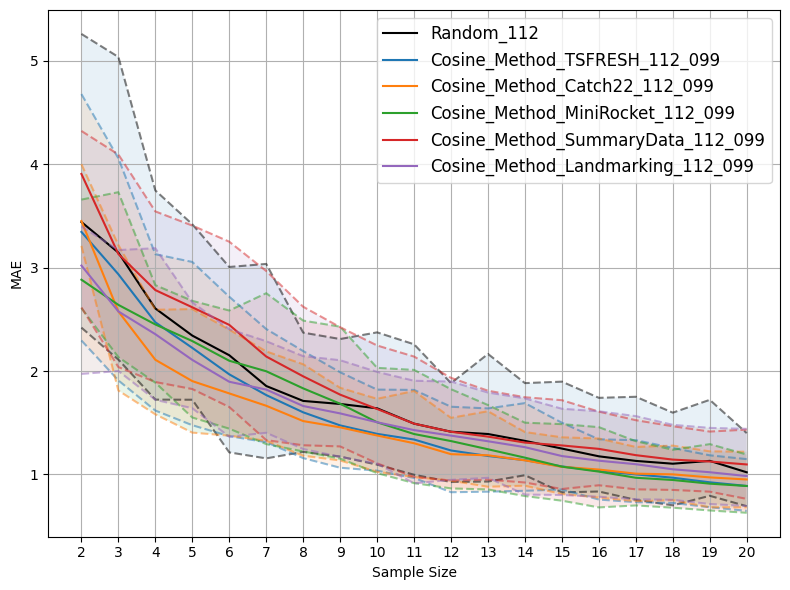

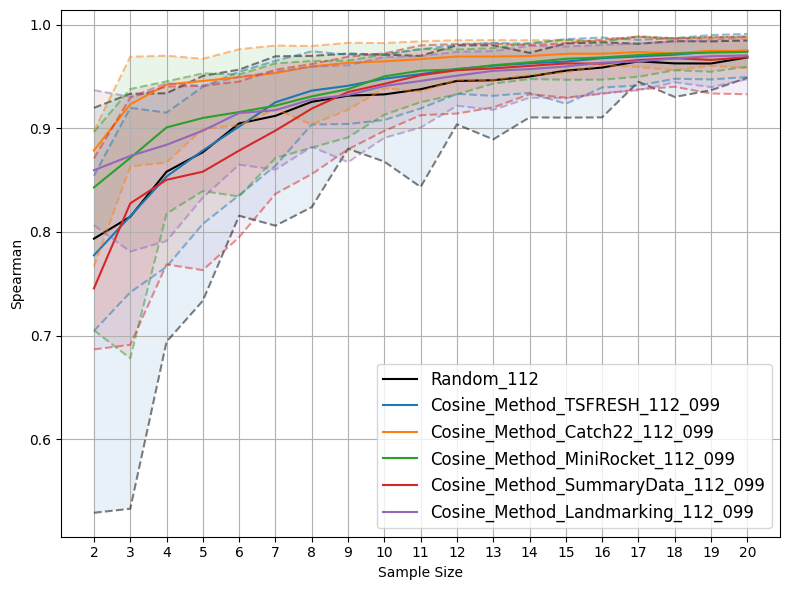

<Figure size 800x600 with 0 Axes>

In [30]:
testing_pipeline(chosen_datasets, metods_data_list, ranks, scores, chosen_datasets, ratio=0.8, models_prefix='',
                 load_res=True, save_results=True, save_checpoints=True)

In [31]:
metods_data_list = [
                    [rand_ind_method, prep_features.values,
                     range(2, 21),
                     False,
                     False,
                     {}, 
                     False,
                     False,
                     'Random_112_099'],
                    # [get_more_different_datasets,
                    #  meta_tsfresh.values,
                    #  range(2, 21),
                    #  False,
                    #  False,
                    #  {'scale_data': False, 'pca_099': True},
                    #  False,
                    #  False,
                    #  'Cosine_Method_SF_TEST_D4'],
                    [k_means_ind,
                     tsf.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False, 
                     'K-Means_S_TSFRESH_112_099'],
                    [k_means_ind,
                     c22.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'K-Means_S_Catch22_112_099'],
                    [k_means_ind,
                     mr.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'K-Means_S_MiniRocket_112_099'],
                    [k_means_ind,
                     sm.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'K-Means_S_SummaryData_112_099'],
                    [k_means_ind,
                     lm.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'K-Means_S_Landmarking_112_099'],
                    ]


Random_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

K-Means_S_TSFRESH_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

K-Means_S_Catch22_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

K-Means_S_MiniRocket_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

K-Means_S_SummaryData_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

K-Means_S_Landmarking_112_099:   0%|          | 0/19 [00:00<?, ?it/s]


=== AUC over mean curves ===
Random_112_099: AUC_MAE=30.7706  AUC_Spearman=16.6194
K-Means_S_TSFRESH_112_099: AUC_MAE=26.336  AUC_Spearman=16.8257
K-Means_S_Catch22_112_099: AUC_MAE=31.9338  AUC_Spearman=16.9625
K-Means_S_MiniRocket_112_099: AUC_MAE=31.5479  AUC_Spearman=16.9707
K-Means_S_SummaryData_112_099: AUC_MAE=31.8427  AUC_Spearman=16.3661
K-Means_S_Landmarking_112_099: AUC_MAE=29.5724  AUC_Spearman=16.8104



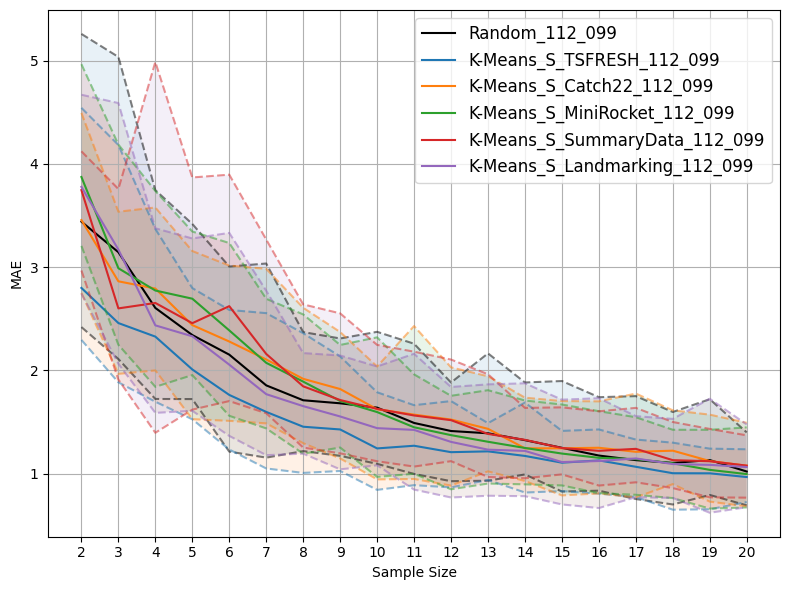

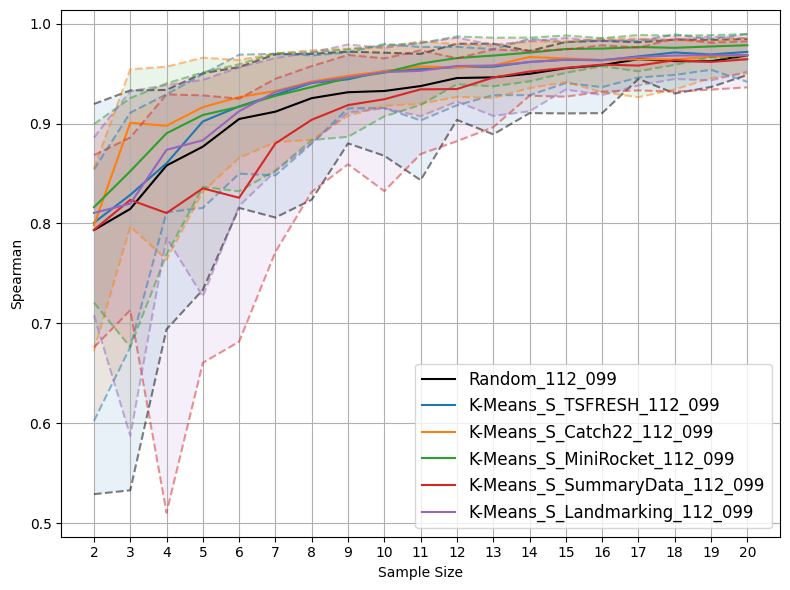

<Figure size 800x600 with 0 Axes>

In [32]:
testing_pipeline(chosen_datasets, metods_data_list, ranks, scores, chosen_datasets, ratio=0.8, models_prefix='',
                 load_res=True, save_results=True, save_checpoints=True)

In [33]:
metods_data_list = [
                    [rand_ind_method, prep_features.values,
                     range(2, 21),
                     False,
                     False,
                     {}, 
                     False,
                     False,
                     'Random_112_099'],
                    # [get_more_different_datasets,
                    #  meta_tsfresh.values,
                    #  range(2, 21),
                    #  False,
                    #  False,
                    #  {'scale_data': False, 'pca_099': True},
                    #  False,
                    #  False,
                    #  'Cosine_Method_SF_TEST_D4'],
                    [get_more_different_datasets_euclid,
                     tsf.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False, 
                     'EuclidMethod_TSFRESH_112_099'],
                    [get_more_different_datasets_euclid,
                     c22.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'EuclidMethod_Catch22_112_099'],
                    [get_more_different_datasets_euclid,
                     mr.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'EuclidMethod_MiniRocket_112_099'],
                    [get_more_different_datasets_euclid,
                     sm.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'EuclidMethod_SummaryData_112_099'],
                    [get_more_different_datasets_euclid,
                     lm.values,
                     range(2, 21),
                     False,
                     False,
                     {'scale_data': False, 'pca_099': True},
                     False,
                     False,
                     'EuclidMethod_Landmarking_112_099'],
                    ]


Loading Random_112_099 results...


EuclidMethod_TSFRESH_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

EuclidMethod_Catch22_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

EuclidMethod_MiniRocket_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

EuclidMethod_SummaryData_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

EuclidMethod_Landmarking_112_099:   0%|          | 0/19 [00:00<?, ?it/s]


=== AUC over mean curves ===
Random_112_099: AUC_MAE=30.7706  AUC_Spearman=16.6194
EuclidMethod_TSFRESH_112_099: AUC_MAE=29.4458  AUC_Spearman=16.839
EuclidMethod_Catch22_112_099: AUC_MAE=29.804  AUC_Spearman=16.7944
EuclidMethod_MiniRocket_112_099: AUC_MAE=29.7931  AUC_Spearman=16.552
EuclidMethod_SummaryData_112_099: AUC_MAE=28.007  AUC_Spearman=16.7001
EuclidMethod_Landmarking_112_099: AUC_MAE=30.4379  AUC_Spearman=16.49



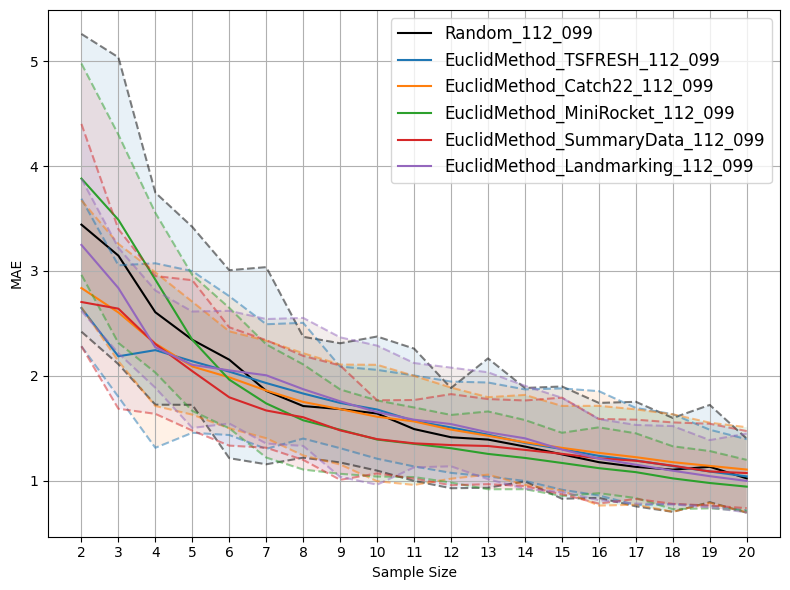

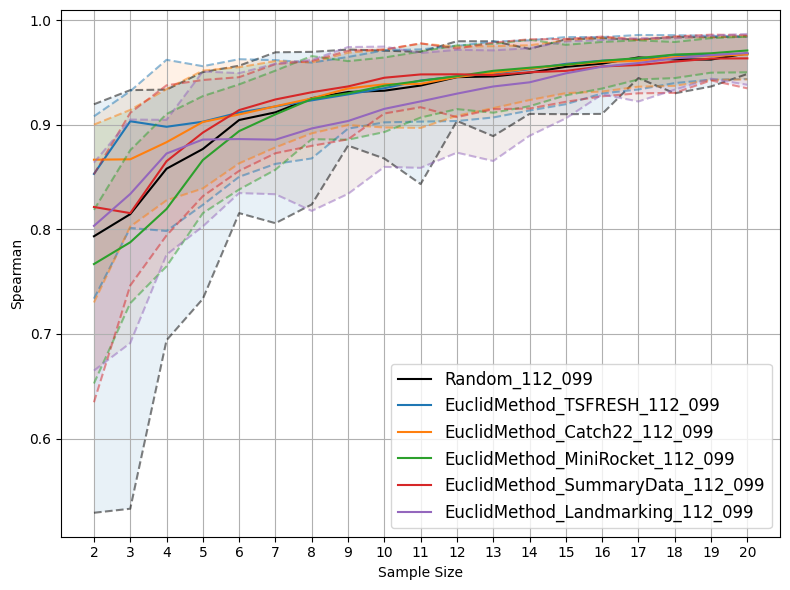

<Figure size 800x600 with 0 Axes>

In [34]:
testing_pipeline(chosen_datasets, metods_data_list, ranks, scores, chosen_datasets, ratio=0.8, models_prefix='',
                 load_res=True, save_results=True, save_checpoints=True)

In [35]:
def a_optimality_ind(data,
                     sample_size: int,
                     model_list=None,
                     scale_data: bool = True,
                     iter: int = 100,
                     alpha: float = 1e-4,
                     random_state: int = 42,
                     pca_099 = False,
                     **kwargs):

    X = np.asarray(data)

    if pca_099:
        X = np.array(StandardScaler().fit_transform(X))
        X = PCA(0.99).fit_transform(X) 

    if scale_data:
        X = StandardScaler().fit_transform(X)

    df = pd.DataFrame(X)
    
    return a_d_optimality_ind(df,
                              sample_size=sample_size,
                              optimality='a',
                              iter=iter,
                              alpha=alpha,
                              random_state=random_state,
                              return_ind=True)


def d_optimality_ind(data,
                     sample_size: int,
                     model_list=None,
                     scale_data: bool = True,
                     iter: int = 100,
                     alpha: float = 1e-4,
                     random_state: int = 42,
                     pca_099 = False,
                     **kwargs):

    X = np.asarray(data)
    
    if pca_099:
        X = np.array(StandardScaler().fit_transform(X))
        X = PCA(0.99).fit_transform(X) 

    if scale_data:
        X = StandardScaler().fit_transform(X)

    df = pd.DataFrame(X)
    return a_d_optimality_ind(df,
                              sample_size=sample_size,
                              optimality='d',
                              iter=iter,
                              alpha=alpha,
                              random_state=random_state,
                              return_ind=True)

In [36]:
metods_data_list = [
    [rand_ind_method, prep_features.values,
     range(2, 21),
     False, False,
     {},
     False, False,
     'Random_112_099'],

    [a_optimality_ind, tsf.values,
     range(2, 21),
     False, False,
     {'scale_data': False, 'iter': 1, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
     False, False,
     'A-opt_TSFRESH_112_099'],

    [a_optimality_ind, c22.values,
     range(2, 21),
     False, False,
     {'scale_data': False, 'iter': 5, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
     False, False,
     'A-opt_Catch22_112_099'],

    # [a_optimality_ind, mr.values,
    #  range(2, 21),
    #  False, False,
    #  {'scale_data': False, 'iter': 1, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
    #  False, False,
    #  'A-opt_MiniRocket'],

    [a_optimality_ind, sm.values,
     range(2, 21),
     False, False,
     {'scale_data': False, 'iter': 5, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
     False, False,
     'A-opt_Summary_112_099'],

    [a_optimality_ind, lm.values,
     range(2, 21),
     False, False,
     {'scale_data': False, 'iter': 5, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
     False, False,
     'A-opt_Landmarking_112_099'],
]

Loading Random_112_099 results...


A-opt_TSFRESH_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

A-opt_Catch22_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

A-opt_Summary_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

A-opt_Landmarking_112_099:   0%|          | 0/19 [00:00<?, ?it/s]


=== AUC over mean curves ===
Random_112_099: AUC_MAE=30.7706  AUC_Spearman=16.6194
A-opt_TSFRESH_112_099: AUC_MAE=27.3953  AUC_Spearman=16.795
A-opt_Catch22_112_099: AUC_MAE=29.644  AUC_Spearman=16.7743
A-opt_Summary_112_099: AUC_MAE=29.6674  AUC_Spearman=16.5532
A-opt_Landmarking_112_099: AUC_MAE=27.1948  AUC_Spearman=16.8735



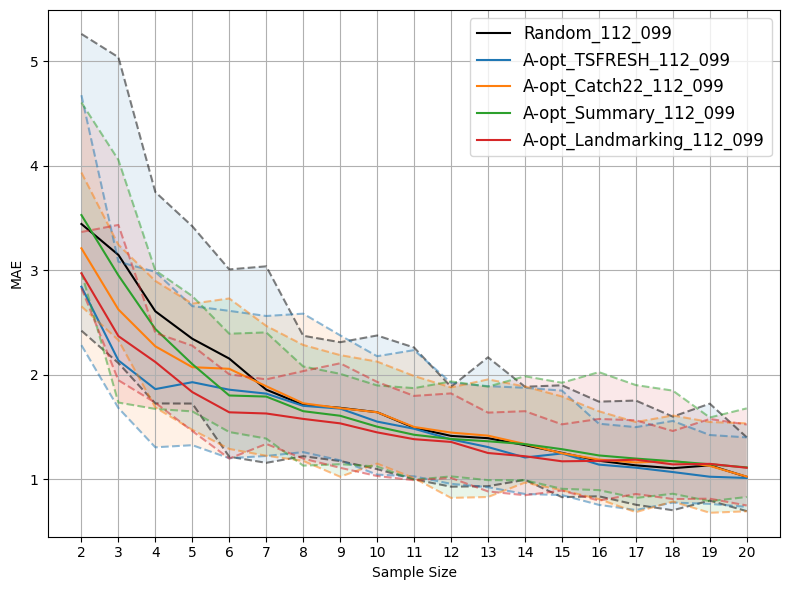

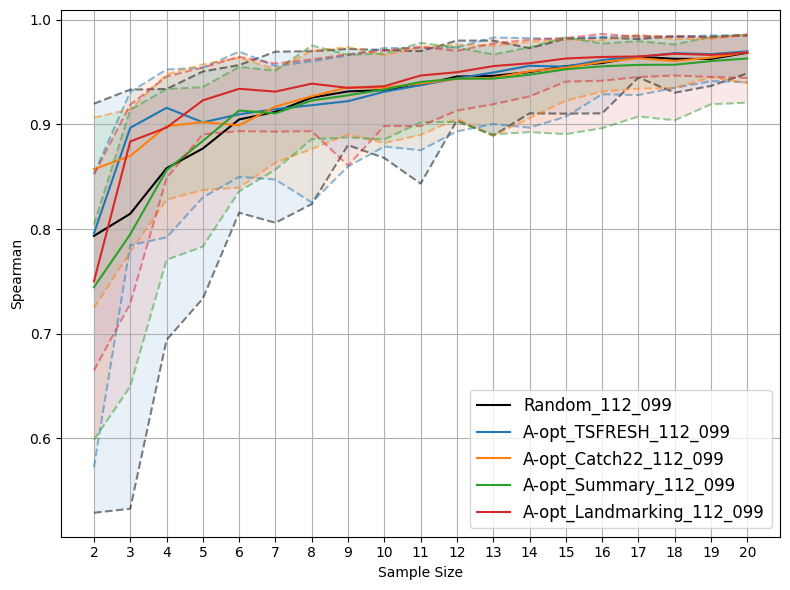

<Figure size 800x600 with 0 Axes>

In [37]:
testing_pipeline(chosen_datasets, metods_data_list, ranks, scores, chosen_datasets, ratio=0.8, models_prefix='',
                 load_res=True, save_results=True, save_checpoints=True)

In [38]:
metods_data_list = [
    [rand_ind_method, prep_features.values,
     range(2, 21),
     False, False,
     {},
     False, False,
     'Random_112_099'],

    [d_optimality_ind, tsf.values,
     range(2, 21),
     False, False,
     {'scale_data': False, 'iter': 1, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
     False, False,
     'D-opt_TSFRESH_112_099'],

    [d_optimality_ind, c22.values,
     range(2, 21),
     False, False,
     {'scale_data': False, 'iter': 5, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
     False, False,
     'D-opt_Catch22_112_099'],

    # [d_optimality_ind, mr.values,
    #  range(2, 21),
    #  False, False,
    #  {'scale_data': False, 'iter': 1, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
    #  False, False,
    #  'D-opt_MiniRocket'],

    [d_optimality_ind, sm.values,
     range(2, 21),
     False, False,
     {'scale_data': False, 'iter': 5, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
     False, False,
     'D-opt_Summary_112_099'],

    [d_optimality_ind, lm.values,
     range(2, 21),
     False, False,
     {'scale_data': False, 'iter': 5, 'alpha': 1e-4, 'random_state': 42, 'pca_099': True},
     False, False,
     'D-opt_Landmarking_112_099'],
]

Loading Random_112_099 results...


D-opt_TSFRESH_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

D-opt_Catch22_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

D-opt_Summary_112_099:   0%|          | 0/19 [00:00<?, ?it/s]

D-opt_Landmarking_112_099:   0%|          | 0/19 [00:00<?, ?it/s]


=== AUC over mean curves ===
Random_112_099: AUC_MAE=30.7706  AUC_Spearman=16.6194
D-opt_TSFRESH_112_099: AUC_MAE=27.2428  AUC_Spearman=16.781
D-opt_Catch22_112_099: AUC_MAE=31.4103  AUC_Spearman=16.7037
D-opt_Summary_112_099: AUC_MAE=29.9629  AUC_Spearman=16.5615
D-opt_Landmarking_112_099: AUC_MAE=27.4989  AUC_Spearman=16.8232



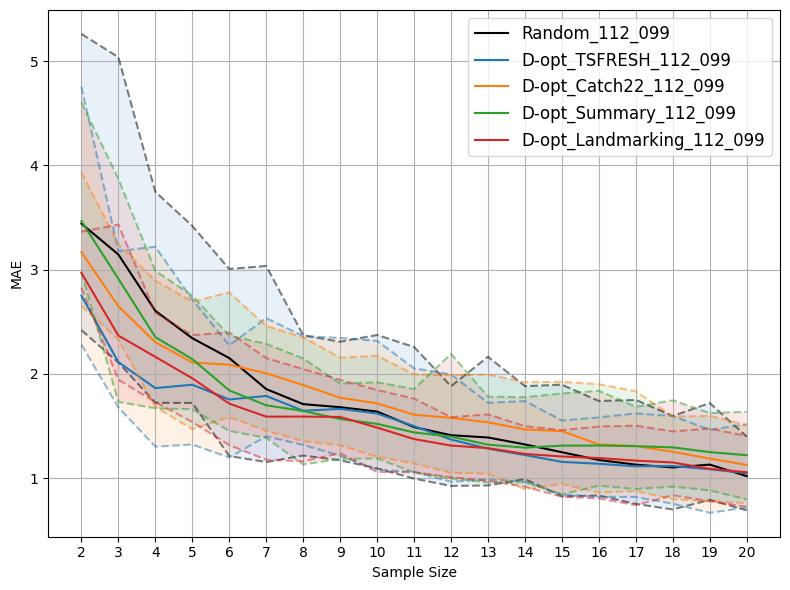

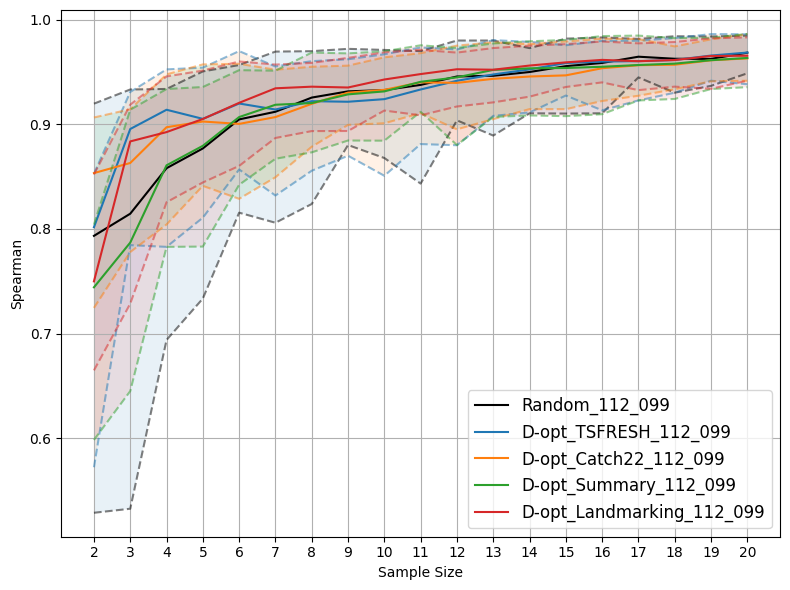

<Figure size 800x600 with 0 Axes>

In [39]:
testing_pipeline(chosen_datasets, metods_data_list, ranks, scores, chosen_datasets, ratio=0.8, models_prefix='',
                 load_res=True, save_results=True, save_checpoints=True)